## Fine Tuning eines Modells auf den [fhswf/german_handwriting Datensatz](https://huggingface.co/datasets/fhswf/german_handwriting)

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2" 
os.environ["WANDB_DISABLED"] = "true"

### Installation der benötigten Bibliotheken

In [2]:
!pip install transformers==4.45.2 sentence-transformers==3.1.1

## Versionen prüfen
- mit diesen Versionen funktioniert der Code

In [3]:
import transformers, torch, datasets
print(transformers.__version__)
print(torch.__version__)
print(datasets.__version__)

4.45.2
2.4.0+cu124
3.3.2


## Daten laden

In [4]:
from datasets import load_dataset

dataset = load_dataset('fhswf/german_handwriting')
print(dataset)
print(dataset.keys())
print(dataset["train"][20])
print(dataset["train"]["text"][20])
print(len(dataset["train"]))

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 10854
    })
})
dict_keys(['train'])
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=2466x82 at 0x7FD98F67ECD0>, 'text': 'minus systematische Ausfälle.'}
minus systematische Ausfälle.
10854


## Auf nones prüfen:

In [5]:
def no_none(data):
    return data["text"] is not None

In [6]:
dataset["train"] = dataset["train"].filter(no_none)

In [7]:
print(len(dataset["train"]))

10844


## Bereinigen der mehrfachen Whitespaces

In [8]:
import re

texts = dataset["train"]["text"]
count = 0
for i, t in enumerate(texts):
    if re.search(r" {2,}", t):
        print(i, repr(t))
        count += 1
        if count == 5:
            break
        

13 '- MCAR    - MAR    - NMAR'
29 '(keine Zufallsschwankung)    -> "seltenere" Gruppen häufiger, aber'
58 '- Abhängig von: - Forschungsfrage    Stichprobe'
62 '- Situationen / Ereignisse   \\ - Texte/Bilder/Filme'
63 '- Individuen | Personen   \\ - soziale Kollektive / Organisationen'


In [9]:
import re

def normalize_text(t: str) -> str:
    t = t.strip()
    t = re.sub(r" {2,}", " ", t)   
    return t


dataset["train"] = dataset["train"].map(lambda x: {"text": normalize_text(x["text"])})

In [10]:
i = 0
print("Nachher:", repr(dataset["train"]["text"][13]))

Nachher: '- MCAR - MAR - NMAR'


## Datensatz aufteilen

- **70% Trainingsdaten**
- **15% Validierungsdaten**
- **15% Testdaten**

In [11]:
from sklearn.model_selection import train_test_split
dataset = dataset["train"].train_test_split(test_size=0.3, seed=42)

train_dataset = dataset["train"]
rest_dataset = dataset["test"]

rest_split = rest_dataset.train_test_split(test_size=0.5, seed=42)

val_dataset = rest_split["train"]
test_dataset = rest_split["test"]

In [12]:
print("training:", len(train_dataset))
print("validation:", len(val_dataset))
print("test:", len(test_dataset))


training: 7590
validation: 1627
test: 1627


## Leichte Augmentierung
- ColorJitter für die Simulation von unterschiedlichen Lichtverhältnissen (mit p=0.8 hohe Wahrscheinlichkeit)
- RandomAffine simmuliert leichtes Kippen bzw. Verschieben (geringere Wahrscheinlichkeit mit p=0.5)
- RandomPerspective simmuliert verschiedene Perspektiven (Wahrscheinlichkeit p=0.15)
- GaussianBlur simmuliert Unschärfe (Wahrscheinlichkeit p=0.2)

In [13]:
from torchvision import transforms
# https://docs.pytorch.org/vision/main/generated/torchvision.transforms.RandomPerspective.html

train_transforms = transforms.Compose([
    # Helligkeit, Kontrast, Sättigung und Farbton anpassen, verändert Samples mit 80% Wahrscheinlichkeit
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.25, contrast=0.30, saturation=0.20, hue=0.03
        )
    ], p=0.8),

    # Geometrie etwas anpassen: 
    transforms.RandomApply([ #mit RandomApply werden die Anpassungen nur manchmal angewendet und das zu einer Wahrscheinlichkeit p
        transforms.RandomAffine(
            degrees=2, # leichte Rotation       
            translate=(0.01, 0.02), # kleine Verschiebung des Bildes
            scale=(0.98, 1.02), # leichtes Zoomen
            shear=1  # Stauchen des Bildes
        )
    ], p=0.5),

    # Leichte Änderung der Perspektive
    transforms.RandomApply([
        transforms.RandomPerspective(distortion_scale=0.1) #Vorher 0.08, distortion_scale: Für Verzerrung
    ], p=0.15),

    # Verschwimmt das Bild etwas
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2))
    ], p=0.2),


])


## GermanHandwriting Dataset-Klasse
- Der DataCollator kann aus den PIL Daten standardmäßig keine Batches formen, deshalb werden die Daten in dieser Klasse vorverarbeitet
- `pixel_values = self.processor(image, return_tensors="pt")` : wandelt das Bild in Pytorch-Tensor um
- `.pixel_valus` : extrahiert die Bilddateien
- `tokenizer(text = ...)` : wandelt Text in Token-IDs um
- `padding="max_length"` : füllt kürzere Texte auf die maximale Länge auf
- `truncation=True` : kürzt längere Texte auf max_target_length

In [14]:
import torch
from torch.utils.data import Dataset # Um eigenen Datensatz zu bearbeiten

class GermanHandwritingDataset(Dataset):
    def __init__(self, ger_dataset, processor, max_target_length=128, transforms=None):
        self.dataset = ger_dataset
        self.processor = processor
        self.max_target_length = max_target_length #Maximale Länge der Textsequenzen
        self.transforms = transforms

    def __len__(self):
        return len(self.dataset) # Wird für die Batch-Verarbeitung gebraucht (DataLoader)

    # Zugriff auf ein einzelnes Sample:
    def __getitem__(self, idx):
        sample = self.dataset[idx]
        image = sample["image"].convert("RGB") # convert("RGB") stellt sicher, dass das Bild 3 Farbkanäle hat
        text = sample["text"]  # der zugehörige Text den das Modell lernen soll
        #print(f"Text: {repr(text)}")
        if self.transforms is not None:
            image = self.transforms(image)

        pixel_values = self.processor(image, return_tensors="pt").pixel_values
        labels = self.processor.tokenizer(text_target=text,padding="max_length",truncation=True,max_length=self.max_target_length).input_ids  # input_ids: Liste der Token-Zahlen
        # Padding Tokens werden hier ignoriert: <PAD> Tokens werden bei zu kurzen Texten als Auffüll-Zeichen genutzt, der Cross-Entropy Loss soll diese ignorieren (geschieht durch setzen von -100)
        labels = [l if l != self.processor.tokenizer.pad_token_id else -100 for l in labels] 

        encoding = {"pixel_values": pixel_values.squeeze(), "labels": torch.tensor(labels)} # encoding hat: pixel_values (Tensor des Bildes), labels (Tensor der Token-IDs des Textes)
        return encoding

## Trainings und Testdatensätze evaluieren
Durch die GermanHandwritingDataset-Klasse wird nun ein PyTorch-Dataset erstellt, das jedes Bild in ienen Tensor umwandelt, jeden Text in Token-IDs umwandelt und die paddings automatisch setzt 

→ Das Ergnis ist dabei ein Dataset-Objekt welches man direkt fürs das Training nutzen kann

In [15]:
from transformers import TrOCRProcessor
from torch.utils.data import Subset
import random

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-large-handwritten")
#processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
train_dataset = GermanHandwritingDataset(train_dataset, processor, transforms=train_transforms)
#train_dataset = GermanHandwritingDataset(train_dataset, processor, transforms=None)
val_dataset = GermanHandwritingDataset(val_dataset, processor, transforms=None)
test_dataset = GermanHandwritingDataset(test_dataset, processor, transforms = None)

#train_hpo_dataset = GermanHandwritingDataset(train_hpo, processor)
#val_hpo_dataset = GermanHandwritingDataset(val_hpo, processor)


In [16]:
#print(train_dataset[0]["pixel_values"])
print("training:", len(train_dataset))
print("validation:", len(val_dataset))
print("test:", len(test_dataset))

training: 7590
validation: 1627
test: 1627


In [17]:
print("train transforms:", train_dataset.transforms is not None)
print("val transforms:", val_dataset.transforms is not None)


train transforms: True
val transforms: False


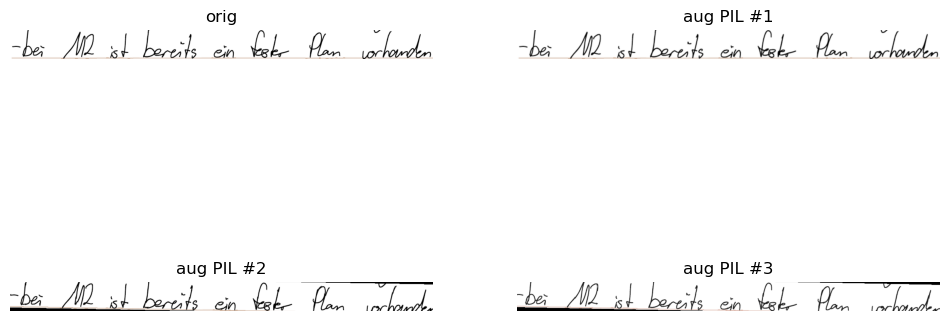

In [18]:
import matplotlib.pyplot as plt

idx = 0
orig = train_dataset.dataset[idx]["image"].convert("RGB")

plt.figure(figsize=(12,6))
plt.subplot(2,2,1); plt.title("orig"); plt.imshow(orig); plt.axis("off")

for i in range(3):
    aug = train_dataset.transforms(orig) if train_dataset.transforms else orig
    plt.subplot(2,2,2+i); plt.title(f"aug PIL #{i+1}")
    plt.imshow(aug); plt.axis("off")

plt.show()


## Model laden:

In [19]:
from transformers import VisionEncoderDecoderModel
import torch
#https://huggingface.co/microsoft/trocr-base-handwritten


model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-large-handwritten")
#model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

VisionEncoderDecoderModel has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-large-handwritten and are newly initialized: [

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-23): 24 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=False)
              (key): Linear(in_features=1024, out_features=1024, bias=False)
              (value): Linear(in_features=1024, out_features=1024, bias=False)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Line

## Finetuning des Modells:
Zuerst alle Parameter des TrOCR-Modells konfigurieren (diese beeinflussen: Wie der Decoder startet und stoppt, wie der Text generiert wird z.B. mit Beam Search, maximale Länge und Vermeidung von Wiederholungen)

Beam Search: https://www.width.ai/post/what-is-beam-search
- betrachtet nicht nur das wahrscheinlichste Wort (wie bei Greedy Search), sondern die N wahrscheinlichsten Optionen (Beam width)
- so kann man mehrere Pfad-Alternativen gleichzeitig verfolgen
- wird beim decoding verwendet (Generiert Token für Token den Text -> Hier wird Beam Search angewendet)

**Quelle für das Finetuning**:https://colab.research.google.com/github/NielsRogge/Transformers-Tutorials/blob/master/TrOCR/Fine_tune_TrOCR_on_IAM_Handwriting_Database_using_Seq2SeqTrainer.ipynb#scrollTo=qO5Q8WYp7DLx

### Konfigurationen von den Special-Tokens und Beam-Search für die Textgenerierung

In [20]:
# interessante Quelle (zum nachrecherchieren): https://huggingface.co/docs/transformers/main/model_doc/trocr   und https://huggingface.co/docs/transformers/main_classes/text_generation
# set special tokens used for creating the decoder_input_ids from the labels
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id #Normalerweise ist Starttoken <BOS> hier aber <CLS>
model.config.pad_token_id = processor.tokenizer.pad_token_id 
# make sure vocab size is set correctly
model.config.vocab_size = model.config.decoder.vocab_size

#in model.config setzen als Fallback
model.config.num_beams = 6
model.config.early_stopping = True
model.config.length_penalty = 1.0
model.config.no_repeat_ngram_size = 3
model.config.max_length = 128

# set beam search parameters
model.config.eos_token_id = processor.tokenizer.sep_token_id

In [21]:
from transformers import GenerationConfig

model.generation_config = GenerationConfig(
    decoder_start_token_id=processor.tokenizer.cls_token_id,
    pad_token_id=processor.tokenizer.pad_token_id,
    eos_token_id=processor.tokenizer.sep_token_id,
    max_length=128,
    num_beams=6,
    no_repeat_ngram_size=3,
    early_stopping=True,
    length_penalty=1.0
)


In [22]:
print("model.config.decoder_start_token_id:", model.config.decoder_start_token_id)
print("generation_config.decoder_start_token_id:", model.generation_config.decoder_start_token_id)


model.config.decoder_start_token_id: 0
generation_config.decoder_start_token_id: 0


## Trainingshyperparameter einstellen:
- Mittels Gradient Accumulation VRAM sparen: bedeutet, dass man nicht bei jedem kleinen Trainings-Batch sofort die Modell-Gewichte updatet, sondern erst mehrere Mini-Batches durchführen, dabei die Gradienten sammeln und danach erst die Gewichte updaten

In [23]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments
# https://huggingface.co/docs/transformers/v4.57.1/en/main_classes/trainer#transformers.Seq2SeqTrainingArguments
training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    learning_rate = 3.5e-05,
    evaluation_strategy="epoch",
    per_device_train_batch_size=32, 
    per_device_eval_batch_size=32,
    warmup_ratio= 0.1,
    seed=42,
    bf16=True,  # Teile des Trainings laufen mit 16 Bit (spart Speicher und beschleunigt das Training)
    output_dir="./TrOCR_finetunes/handwritten_large_finetune_aug", #Verzeichnis in dem Modelle etc. gespeichert werden
    logging_steps=20,
    save_strategy="epoch",
    num_train_epochs=10,

)

/opt/conda/lib/python3.11/site-packages/transformers/training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [24]:
#print(training_args.warmup_ratio, training_args.bf16, training_args.learning_rate)
print(training_args.per_device_train_batch_size)
print(training_args.optim)
print(training_args.warmup_ratio)

32
OptimizerNames.ADAMW_TORCH
0.1


## CER (Character Error Rate):
Quelle: https://galileo.ai/blog/character-error-rate-cer-metric
CER misst die Genauigkeit eines Textes auf Zeichenebene.
- berechnet wie viele Einfügungen, Löschungen oder Ersetzungen notwendig sind, um den vorhergesagten Textz in den originalen Text zu überführen.

$CER = \frac{(I + D + S)}{N}$
- $I$ = Anzahl der eingefügten Zeichen
- $D$ = Anzahl der gelöschten Zeichen
- $S$ = Anzahl der ersetzten Zeichen
- $N$ = Gesamtanzahl der Zeichen im Referenztext

Beispiel:
- Referenz-Text: **"Die Katze springt"**
- Vorhersage: **"Die Ketze pringh"**

→ I = 1 (**s** fehlt in springt), S = 2 (**e** → **a**, **h** → **t**)

$CER = \frac{(1 + 0 + 2)}{17}$ ≈ 0.17 = 17%

## WER (Word Error Rate)
WER zeigt, wie viele Wörter in einem erkannten Text nicht mit dem richtigen Text übereinstimmen.

$ WER = \frac{S + D + I}{N} = \frac{S + D + I}{S + D + C} $
- $S$ – Anzahl der Substitutionen (falsche Wörter)  
- $D$ – Anzahl der Deletionen (fehlende Wörter)  
- $I$ – Anzahl der Insertionen (zusätzliche Wörter)  
- $C$ – Anzahl der korrekt erkannten Wörter  
- $N$ – Gesamtzahl der Wörter in der Referenz (N = S + D + C)


## Character Error Rate (CER) und Word Error Rate (WER) laden

In [25]:
from evaluate import load
cer = load("cer")
wer = load("wer")

## Berechnung des CER & WER

In [26]:
# https://galileo.ai/blog/character-error-rate-cer-metric
def compute_metrics(pred):
    labels_ids = pred.label_ids # die richtigen Token-IDs
    pred_ids = pred.predictions # die Vorhergesagten Token-IDs

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True) # Tokens in lesbaren Text umwandeln
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id # Padding ignorieren
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True) # Richtige Labels auch in Text umwandeln

    cer_score = cer.compute(predictions=pred_str, references=label_str) # Vergleich des generierten Textes mit Referenztext
    wer_score = wer.compute(predictions=pred_str, references=label_str)

    return {"cer": cer_score, "wer": wer_score}

## Trainieren des Modells
- dazu eignet sich der Seq2Seq-Trainer besonders, da eine Generierungsaufgabe (Bild -> Text) vorliegt

In [27]:
from transformers import default_data_collator
from transformers import Trainer

torch.cuda.empty_cache()
# https://huggingface.co/docs/transformers/main_classes/trainer

trainer = Seq2SeqTrainer(
    model=model,
    tokenizer=processor.tokenizer,
    args=training_args, # Sind oben definiert
    compute_metrics=compute_metrics, # Wichtig für Evaluation (berechnet den CER nach jeder Evaluation)
    #compute_metrics=None, #teilweise testen (wegen OOM)
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    #eval_dataset=small_eval_dataset,
    data_collator=default_data_collator,  # collator: Erstellt Batches aus den Elementen der Trainings oder Validierungsdaten
)

#trainer.train(resume_from_checkpoint="TrOCR_finetunes/handwritten_large_finetune_decay_warmup/checkpoint-2137")

trainer.train()
processor.save_pretrained("./TrOCR_finetunes/handwritten_large_finetune_aug")

Epoch,Training Loss,Validation Loss,Cer,Wer
1,0.779500,0.629450,0.096282,0.321406
2,0.571900,0.453887,0.060178,0.234791
3,0.401500,0.369612,0.050149,0.200660
4,0.281100,0.337183,0.046656,0.185193
5,0.217600,0.286248,0.037423,0.160755
6,0.141900,0.267549,0.036307,0.152093
7,0.105400,0.250675,0.031799,0.141163
8,0.076700,0.226931,0.028060,0.127346
9,0.048400,0.215515,0.027277,0.121365
10,0.038200,0.205814,0.024422,0.113013


/opt/conda/lib/python3.11/site-packages/transformers/modeling_utils.py:2618: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 128, 'early_stopping': True, 'num_beams': 6, 'no_repeat_ngram_size': 3}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


[]

## Evaluieren auf Testdatensatz (ohne Augmentierung)

In [28]:
from transformers import default_data_collator
from transformers import VisionEncoderDecoderModel

trained_model = VisionEncoderDecoderModel.from_pretrained("TrOCR_finetunes/handwritten_large_finetune_no_aug/checkpoint-2380/")
processor = TrOCRProcessor.from_pretrained("./TrOCR_finetunes/handwritten_large_finetune_no_aug")


t_trainer = Seq2SeqTrainer(
    model=trained_model,
    tokenizer=processor.tokenizer,
    args=training_args, # Sind oben definiert
    compute_metrics=compute_metrics,
    #train_dataset=train_dataset,
    #eval_dataset=val_dataset,
    eval_dataset=test_dataset,
    #eval_dataset=small_eval_dataset,
    data_collator=default_data_collator  # collator: Erstellt Batches aus den Elementen der Trainings oder Validierungsdaten
)

test_res = t_trainer.evaluate()

print(test_res)

{'eval_loss': 0.25833848118782043, 'eval_model_preparation_time': 0.0088, 'eval_cer': 0.027895988025709507, 'eval_wer': 0.12982273201251304, 'eval_runtime': 233.3341, 'eval_samples_per_second': 6.973, 'eval_steps_per_second': 0.219}


## Evaluieren auf Testdatensatz (mit Augmentierung)

In [28]:
from transformers import default_data_collator
from transformers import VisionEncoderDecoderModel

trained_model = VisionEncoderDecoderModel.from_pretrained("TrOCR_finetunes/handwritten_large_finetune_aug/checkpoint-2380/")
processor = TrOCRProcessor.from_pretrained("./TrOCR_finetunes/handwritten_large_finetune_aug")


t_trainer = Seq2SeqTrainer(
    model=trained_model,
    tokenizer=processor.tokenizer,
    args=training_args, # Sind oben definiert
    compute_metrics=compute_metrics,
    #train_dataset=train_dataset,
    #eval_dataset=val_dataset,
    eval_dataset=test_dataset,
    #eval_dataset=small_eval_dataset,
    data_collator=default_data_collator  # collator: Erstellt Batches aus den Elementen der Trainings oder Validierungsdaten
)

test_res = t_trainer.evaluate()

print(test_res)

{'eval_loss': 0.22480882704257965, 'eval_model_preparation_time': 0.0082, 'eval_cer': 0.026267132333519207, 'eval_wer': 0.11981230448383733, 'eval_runtime': 230.5204, 'eval_samples_per_second': 7.058, 'eval_steps_per_second': 0.221}


## FH-SWF Modell

In [29]:
from transformers import default_data_collator
from transformers import VisionEncoderDecoderModel

trained_model = VisionEncoderDecoderModel.from_pretrained("fhswf/TrOCR_german_handwritten")
processor = TrOCRProcessor.from_pretrained("fhswf/TrOCR_german_handwritten")


t_trainer = Seq2SeqTrainer(
    model=trained_model,
    tokenizer=processor.tokenizer,
    args=training_args, # Sind oben definiert
    compute_metrics=compute_metrics,
    #train_dataset=train_dataset,
    #eval_dataset=val_dataset,
    eval_dataset=test_dataset,
    #eval_dataset=small_eval_dataset,
    data_collator=default_data_collator  # collator: Erstellt Batches aus den Elementen der Trainings oder Validierungsdaten
)

test_res = t_trainer.evaluate()

print(test_res)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.23G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/957 [00:00<?, ?B/s]

/opt/conda/lib/python3.11/site-packages/transformers/generation/utils.py:1338: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


{'eval_loss': 0.1659637689590454, 'eval_model_preparation_time': 0.0085, 'eval_cer': 0.014836882346898343, 'eval_wer': 0.05539906103286385, 'eval_runtime': 424.12, 'eval_samples_per_second': 3.836, 'eval_steps_per_second': 0.12}


## Vergleich zum untrainierten Modell

In [30]:
from transformers import default_data_collator
device = torch.device("cuda:0")  
processor_base = TrOCRProcessor.from_pretrained('microsoft/trocr-large-handwritten')
base_model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-large-handwritten').to(device)


# Gleiche Configs wie beim Training
base_model.config.decoder_start_token_id = processor_base.tokenizer.cls_token_id
base_model.config.pad_token_id = processor_base.tokenizer.pad_token_id
base_model.config.vocab_size = base_model.config.decoder.vocab_size
base_model.config.eos_token_id = processor_base.tokenizer.sep_token_id

from transformers import GenerationConfig
base_model.generation_config = GenerationConfig(
    decoder_start_token_id=processor_base.tokenizer.cls_token_id,
    pad_token_id=processor_base.tokenizer.pad_token_id,
    eos_token_id=processor_base.tokenizer.sep_token_id,
    max_length=128,
    num_beams=6,
    no_repeat_ngram_size=3,
    early_stopping=True,
    length_penalty=1.0
)

base_trainer = Seq2SeqTrainer(
    model=base_model,
    tokenizer=processor_base.tokenizer,
    args=training_args,
    compute_metrics=compute_metrics,
    eval_dataset=test_dataset,
    data_collator=default_data_collator
)

base_res = base_trainer.evaluate()
print(base_res)

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-large-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'eval_loss': 6.107980251312256, 'eval_model_preparation_time': 0.0075, 'eval_cer': 0.29755231414903294, 'eval_wer': 0.9197080291970803, 'eval_runtime': 203.3484, 'eval_samples_per_second': 8.001, 'eval_steps_per_second': 0.251}


In [31]:
from PIL import Image
trained_model = VisionEncoderDecoderModel.from_pretrained("./TrOCR_finetunes/handwritten_large_finetune_aug_april_3/checkpoint-2380").to(device) 
processor_trained = TrOCRProcessor.from_pretrained("microsoft/trocr-large-handwritten")

device = "cuda" if torch.cuda.is_available() else "cpu"
base_model.to(device)

# Erstes Sample aus Testdatensatz
sample = test_dataset[0]
pixel_values = sample["pixel_values"].unsqueeze(0).to(device)

generated_ids = base_model.generate(pixel_values)
generated_text = processor_base.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Vorhersage-Baseline:", generated_text)

generated_ids = trained_model.generate(pixel_values)
generated_text = processor_trained.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Vorhersage-Trained:", generated_text)

# Ground Truth anzeigen
label_ids = sample["labels"].clone()
label_ids[label_ids == -100] = processor_base.tokenizer.pad_token_id
label_text = processor_base.tokenizer.decode(label_ids, skip_special_tokens=True)
print("Ground Truth:", label_text)

Vorhersage-Baseline: Problem do Spiel and dieser belt must
Vorhersage-Trained: Das Leben als Spiel auf dieser Welt mit
Ground Truth: Das Leben als Spiel auf dieser Welt mit


## (fine tuned) Modell testen
- Nun wird das Modell mit einer handgeschriebenen Zeile getestet:
![Beispielbild](crop_0.png)

In [34]:
from PIL import Image

#trained_model = VisionEncoderDecoderModel.from_pretrained("checkpoint-1440")
device = "cuda" if torch.cuda.is_available() else "cpu"
trained_model.to(device)

image_path = "crop_0.png"
image = Image.open("crop_0.png").convert("RGB")

pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
generated_ids = trained_model.generate(pixel_values)

generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(generated_text)

Ab wann sollte man ein Thema offiziell anmelden?
